In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import random
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchvision.utils import make_grid
import torch.nn.functional as F
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from sklearn.model_selection import train_test_split  
from torchinfo import summary
torch.manual_seed(689)

In [3]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Hyperparameters
NUM_EPOCHS = 39
BATCH_SIZE = 32
LEARNING_RATE = 0.00015
LAMBDA_IDENTITY = 5
LAMBDA_CYCLE = 10
LOAD_SHAPE = 128
TARGET_SHAPE = 128
DIM_A = 3
DIM_B = 3

# Dataset paths
DATA_ROOT = '/kaggle/input/tyyitiu/photo2painting-v2/'
PHOTO_DIR = os.path.join(DATA_ROOT, 'trainB') 
PAINT_DIR = os.path.join(DATA_ROOT, 'trainA')  

TEST_PHOTO_DIR = os.path.join(DATA_ROOT, 'testB')
TEST_PAINT_DIR = os.path.join(DATA_ROOT, 'testA')

# Training report setup
COLUMN_NAMES = ["Epoch", "Gen Loss", "Disc Loss", "Val Loss"]
COLUMN_WIDTHS = [18, 18, 18, 18]
COLUMN_ALIGNS = [">", ">", ">", ">"]

Using device: cuda


In [12]:
def generate_header():
    segmented_border_parts = ["-" * (w + 2) for w in COLUMN_WIDTHS]
    segmented_border = f"+{'+'.join(segmented_border_parts)}+"
    total_width = len(segmented_border) - 2
    full_width_border = f"+{'-' * total_width}+"
    title_text = "TRAINING REPORTS"
    title_line = f"|{' ' * ((total_width - len(title_text)) // 2)}{title_text}{' ' * ((total_width - len(title_text) + 1) // 2)}|"
    header_parts = []
    for i, name in enumerate(COLUMN_NAMES):
        width = COLUMN_WIDTHS[i]
        align = COLUMN_ALIGNS[i]
        adjusted_width = width + 2
        header_parts.append(f"{name:{align}{adjusted_width}}")
    header_line = f"|{'|'.join(header_parts)}|"
    table_parts = [full_width_border, title_line, segmented_border, header_line, segmented_border]
    return "\n".join(table_parts)

def generate_data_line(epoch_data):
    row_parts = []
    for i, value in enumerate(epoch_data):
        width = COLUMN_WIDTHS[i]
        align = COLUMN_ALIGNS[i]
        formatted_value = f"{value:.8f}" if isinstance(value, float) else str(value)
        adjusted_width = width + 2
        row_parts.append(f"{formatted_value:{align}{adjusted_width}}")
    return f"|{'|'.join(row_parts)}|"

def get_segmented_border() -> str:
    segmented_border_parts = ["-" * (w + 2) for w in COLUMN_WIDTHS]
    return f"+{'+'.join(segmented_border_parts)}+"

def print_training_report(checkpoint_path='/kaggle/working/last_checkpoint.pth'):
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path)
        completed_epochs_data = checkpoint.get('completed_epochs_data', [])
        print(generate_header())
        for data in completed_epochs_data:
            print(generate_data_line(data))
            print(get_segmented_border())
    else:
        print("No checkpoint found")

print_training_report()

+-----------------------------------------------------------------------------------+
|                                 TRAINING REPORTS                                  |
+--------------------+--------------------+--------------------+--------------------+
|               Epoch|            Gen Loss|           Disc Loss|            Val Loss|
+--------------------+--------------------+--------------------+--------------------+
|                   1|          3.72611391|          0.30570305|          2.76648529|
+--------------------+--------------------+--------------------+--------------------+
|                   2|          2.78364931|          0.24655354|          2.26839313|
+--------------------+--------------------+--------------------+--------------------+
|                   3|          2.56734749|          0.23637920|          2.72778771|
+--------------------+--------------------+--------------------+--------------------+
|                   4|          2.80851916|          0

In [5]:
class UnpairedPhotoDataset(Dataset):
    def __init__(self, photo_files, paint_files, transform=None, transformpa=None):
        self.photos = photo_files
        self.paints = paint_files * 3
        random.shuffle(self.paints)     
        self.transform = transform
        self.transformpa = transformpa

    def __len__(self):
        return len(self.photos)

    def __getitem__(self, idx):
        photo = self.transform(Image.open(self.photos[idx]))
        paint_idx = idx % len(self.paints)
        paint = self.transformpa(Image.open(self.paints[paint_idx]))
        
        # Normalize [-1,1]
        if photo.shape[0] != 3: photo = photo.repeat(3, 1, 1)
        if paint.shape[0] != 3: paint = paint.repeat(3, 1, 1)
        return (photo - 0.5) * 2, (paint - 0.5) * 2  # real_photo, real_paint

class ResidualBlock(nn.Module):
    def __init__(self, input_channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, input_channels, kernel_size=3, padding=1, padding_mode='reflect')
        self.conv2 = nn.Conv2d(input_channels, input_channels, kernel_size=3, padding=1, padding_mode='reflect')
        self.instancenorm = nn.InstanceNorm2d(input_channels)
        self.activation = nn.ReLU()

    def forward(self, x):
        original_x = x.clone()
        x = self.conv1(x)
        x = self.instancenorm(x)
        x = self.activation(x)
        x = self.conv2(x)
        x = self.instancenorm(x)
        return original_x + x

class ContractingBlock(nn.Module):
    def __init__(self, input_channels, use_bn=True, kernel_size=3, activation='relu'):
        super(ContractingBlock, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, input_channels * 2, kernel_size=kernel_size, padding=1, stride=2, padding_mode='reflect')
        self.activation = nn.ReLU() if activation == 'relu' else nn.LeakyReLU(0.2)
        if use_bn:
            self.instancenorm = nn.InstanceNorm2d(input_channels * 2)
        self.use_bn = use_bn

    def forward(self, x):
        x = self.conv1(x)
        if self.use_bn:
            x = self.instancenorm(x)
        x = self.activation(x)
        return x

class ExpandingBlock(nn.Module):
    def __init__(self, input_channels, use_bn=True):
        super(ExpandingBlock, self).__init__()
        self.conv1 = nn.ConvTranspose2d(input_channels, input_channels // 2, kernel_size=3, stride=2, padding=1, output_padding=1)
        if use_bn:
            self.instancenorm = nn.InstanceNorm2d(input_channels // 2)
        self.use_bn = use_bn
        self.activation = nn.LeakyReLU()

    def forward(self, x):
        x = self.conv1(x)
        if self.use_bn:
            x = self.instancenorm(x)
        x = self.activation(x)
        return x

class FeatureMapBlock(nn.Module):
    def __init__(self, input_channels, output_channels):
        super(FeatureMapBlock, self).__init__()
        self.conv = nn.Conv2d(input_channels, output_channels, kernel_size=7, padding=3, padding_mode='reflect')

    def forward(self, x):
        x = self.conv(x)
        return x

class Generator(nn.Module):
    def __init__(self, input_channels, output_channels, hidden_channels=64):
        super(Generator, self).__init__()
        self.upfeature = FeatureMapBlock(input_channels, hidden_channels)
        self.contract1 = ContractingBlock(hidden_channels)
        self.contract2 = ContractingBlock(hidden_channels * 2)
        res_mult = 4
        self.res0 = ResidualBlock(hidden_channels * res_mult)
        self.res1 = ResidualBlock(hidden_channels * res_mult)
        self.res2 = ResidualBlock(hidden_channels * res_mult)
        self.res3 = ResidualBlock(hidden_channels * res_mult)
        self.res4 = ResidualBlock(hidden_channels * res_mult)
        self.res5 = ResidualBlock(hidden_channels * res_mult)
        self.res6 = ResidualBlock(hidden_channels * res_mult)
        self.res7 = ResidualBlock(hidden_channels * res_mult)
        self.res8 = ResidualBlock(hidden_channels * res_mult)
        self.expand2 = ExpandingBlock(hidden_channels * 4)
        self.expand3 = ExpandingBlock(hidden_channels * 2)
        self.downfeature = FeatureMapBlock(hidden_channels, output_channels)
        self.tanh = torch.nn.Tanh()

    def forward(self, x):
        x0 = self.upfeature(x)
        x1 = self.contract1(x0)
        x2 = self.contract2(x1)
        x3 = self.res0(x2)
        x4 = self.res1(x3)
        x5 = self.res2(x4)
        x6 = self.res3(x5)
        x7 = self.res4(x6)
        x8 = self.res5(x7)
        x9 = self.res6(x8)
        x10 = self.res7(x9)
        x11 = self.res8(x10)
        x12 = self.expand2(x11)
        x13 = self.expand3(x12)
        xn = self.downfeature(x13)
        return self.tanh(xn)

class Discriminator(nn.Module):
    def __init__(self, input_channels, hidden_channels=64):
        super(Discriminator, self).__init__()
        self.upfeature = FeatureMapBlock(input_channels, hidden_channels)
        self.contract1 = ContractingBlock(hidden_channels, use_bn=False, kernel_size=4, activation='relu')
        self.contract2 = ContractingBlock(hidden_channels * 2, kernel_size=4, activation='lrelu')
        self.contract3 = ContractingBlock(hidden_channels * 4, kernel_size=4, activation='relu')
        self.contract4 = ContractingBlock(hidden_channels * 8, kernel_size=4, activation='lrelu')
        self.final = nn.Conv2d(hidden_channels * 16, 1, kernel_size=1)

    def forward(self, x):
        x0 = self.upfeature(x)
        x1 = self.contract1(x0)
        x2 = self.contract2(x1)
        x3 = self.contract3(x2)
        x4 = self.contract4(x3)
        xn = self.final(x4)
        return xn

In [6]:
# Data transforms
transform = transforms.Compose([
    transforms.Resize(LOAD_SHAPE),
    transforms.RandomCrop(TARGET_SHAPE),
    transforms.RandomEqualize(p=0.35),
    transforms.RandomPosterize(bits=4,p=0.55),
    transforms.RandomResizedCrop(TARGET_SHAPE),
    transforms.RandomHorizontalFlip(),
    transforms.GaussianBlur(kernel_size=(7, 5), sigma=(0.1, 2.5)),
    transforms.RandomAdjustSharpness(sharpness_factor=5),
    transforms.ToTensor(),
])

# Tranformpaint
transformpa = transforms.Compose([
    transforms.Resize(LOAD_SHAPE), 
    transforms.CenterCrop(TARGET_SHAPE), 
    transforms.RandomHorizontalFlip(),
    transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.0)),
    transforms.ToTensor()
])

## Tranform val/test
transform1 = transforms.Compose([
    transforms.Resize(LOAD_SHAPE), 
    transforms.CenterCrop(TARGET_SHAPE), 
    transforms.ToTensor()
])
# LOAD + SPLIT 80/10/10
photo_files = sorted(glob.glob(PHOTO_DIR + '/*'))
paint_files = sorted(glob.glob(PAINT_DIR + '/*'))

# SPLIT PHOTOS
train_photos, temp = train_test_split(photo_files, test_size=0.2, random_state=689)
val_photos, test_photos = train_test_split(temp, test_size=0.5, random_state=689) 

# Datasets
train_ds = UnpairedPhotoDataset(train_photos, paint_files, transform, transformpa)
val_ds = UnpairedPhotoDataset(val_photos, paint_files, transform1, transformpa)
test_ds = UnpairedPhotoDataset(test_photos, paint_files, transform1, transformpa)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,          
    num_workers=4,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,          
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)


gen = Generator(DIM_A, DIM_B).to(device)  # Photo → Paint
disc = Discriminator(DIM_B).to(device)    # Disc Paint

# Visualization function
def show_tensor_images(image_tensor, num_images=9, size=(3, 128, 128)):
    image_tensor = (image_tensor + 1) / 2
    image_unflat = image_tensor.detach().cpu().view(-1, *size)
    image_grid = make_grid(image_unflat[:num_images], nrow=3)
    plt.figure(figsize=(5,5))
    plt.imshow(image_grid.permute(1, 2, 0).squeeze())
    plt.axis('off')
    plt.show()

gen_AB = Generator(DIM_A, DIM_B).to(device)
gen_BA = Generator(DIM_B, DIM_A).to(device)
disc_B = Discriminator(DIM_B).to(device)

print(f"Photos: Train={len(train_photos)} | Val={len(val_photos)} | Test={len(test_photos)}")
print(f"Paint len before: {len(paint_files)}")
print(f"Paint after repeat: {len(train_ds.paints)}")

Photos: Train=16288 | Val=2036 | Test=2037
Paint len before: 2070
Paint after repeat: 6210


In [7]:
print("Generator Summary:")
summary(gen, input_size=(DIM_A, TARGET_SHAPE, TARGET_SHAPE))  # Input shape: channels, height, width

Generator Summary:


Layer (type:depth-idx)                   Output Shape              Param #
Generator                                [3, 128, 128]             --
├─FeatureMapBlock: 1-1                   [64, 128, 128]            --
│    └─Conv2d: 2-1                       [64, 128, 128]            9,472
├─ContractingBlock: 1-2                  [128, 64, 64]             --
│    └─Conv2d: 2-2                       [128, 64, 64]             73,856
│    └─InstanceNorm2d: 2-3               [128, 64, 64]             --
│    └─ReLU: 2-4                         [128, 64, 64]             --
├─ContractingBlock: 1-3                  [256, 32, 32]             --
│    └─Conv2d: 2-5                       [256, 32, 32]             295,168
│    └─InstanceNorm2d: 2-6               [256, 32, 32]             --
│    └─ReLU: 2-7                         [256, 32, 32]             --
├─ResidualBlock: 1-4                     [256, 32, 32]             --
│    └─Conv2d: 2-8                       [256, 32, 32]             590,08

In [8]:
print("Discriminator Summary:")
summary(disc, input_size=(DIM_B, TARGET_SHAPE, TARGET_SHAPE))

Discriminator Summary:


Layer (type:depth-idx)                   Output Shape              Param #
Discriminator                            [1, 8, 8]                 --
├─FeatureMapBlock: 1-1                   [64, 128, 128]            --
│    └─Conv2d: 2-1                       [64, 128, 128]            9,472
├─ContractingBlock: 1-2                  [128, 64, 64]             --
│    └─Conv2d: 2-2                       [128, 64, 64]             131,200
│    └─ReLU: 2-3                         [128, 64, 64]             --
├─ContractingBlock: 1-3                  [256, 32, 32]             --
│    └─Conv2d: 2-4                       [256, 32, 32]             524,544
│    └─InstanceNorm2d: 2-5               [256, 32, 32]             --
│    └─LeakyReLU: 2-6                    [256, 32, 32]             --
├─ContractingBlock: 1-4                  [512, 16, 16]             --
│    └─Conv2d: 2-7                       [512, 16, 16]             2,097,664
│    └─InstanceNorm2d: 2-8               [512, 16, 16]           

In [9]:
adv_criterion = nn.MSELoss()
recon_criterion = nn.L1Loss()

gen_params = list(gen_AB.parameters()) + list(gen_BA.parameters())
gen_opt = optim.Adam(gen_params, lr=LEARNING_RATE, betas=(0.5, 0.999))
disc_opt = optim.Adam(disc_B.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))

def get_disc_loss(real_paint, fake_paint, disc):
    pred_real = disc(real_paint)
    pred_fake = disc(fake_paint.detach())
    loss_real = adv_criterion(pred_real, torch.ones_like(pred_real))
    loss_fake = adv_criterion(pred_fake, torch.zeros_like(pred_fake))
    return (loss_real + loss_fake) / 2

def get_gen_loss(real_photo, real_paint, gen_AB, gen_BA, disc_B):
    fake_paint = gen_AB(real_photo)
    pred_fake = disc_B(fake_paint)
    adv_loss = adv_criterion(pred_fake, torch.ones_like(pred_fake))
    cycled_photo = gen_BA(fake_paint)
    cycle_loss = recon_criterion(cycled_photo, real_photo)
    identity_paint = gen_AB(real_paint)
    id_loss = recon_criterion(identity_paint, real_paint)
    total_gen_loss = adv_loss + LAMBDA_CYCLE * cycle_loss + LAMBDA_IDENTITY * id_loss
    return total_gen_loss, fake_paint

Loaded epoch 31
+-----------------------------------------------------------------------------------+
|                                 TRAINING REPORTS                                  |
+--------------------+--------------------+--------------------+--------------------+
|               Epoch|            Gen Loss|           Disc Loss|            Val Loss|
+--------------------+--------------------+--------------------+--------------------+
|                   1|          3.72611391|          0.30570305|          2.76648529|
+--------------------+--------------------+--------------------+--------------------+
|                   2|          2.78364931|          0.24655354|          2.26839313|
+--------------------+--------------------+--------------------+--------------------+
|                   3|          2.56734749|          0.23637920|          2.72778771|
+--------------------+--------------------+--------------------+--------------------+
|                   4|          2.8085

Overall Progress:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch 32:   0%|          | 0/509 [00:00<?, ?it/s]

-- Batches for Epoch 32 --: 0it [00:00, ?it/s]

|                  32|          2.18127033|          0.01593634|          1.39194498|
+--------------------+--------------------+--------------------+--------------------+
Displaying 9 original photos and 9 generated paintings after Epoch 32
Original Photos:


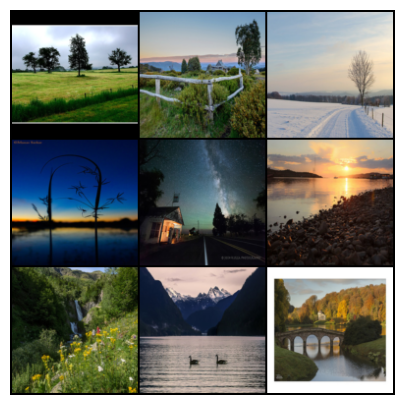

Generated Paintings:


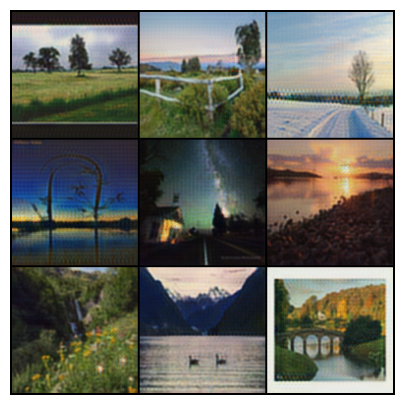

Epoch 33:   0%|          | 0/509 [00:00<?, ?it/s]

-- Batches for Epoch 33 --: 0it [00:00, ?it/s]

|                  33|          2.16243726|          0.01368474|          1.26718013|
+--------------------+--------------------+--------------------+--------------------+
Displaying 9 original photos and 9 generated paintings after Epoch 33
Original Photos:


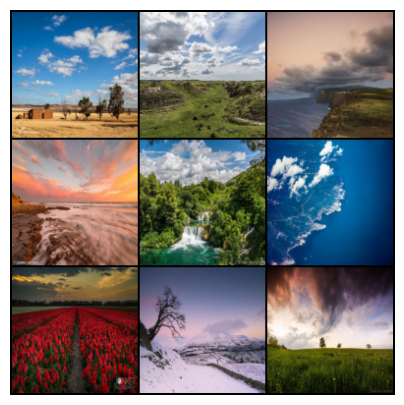

Generated Paintings:


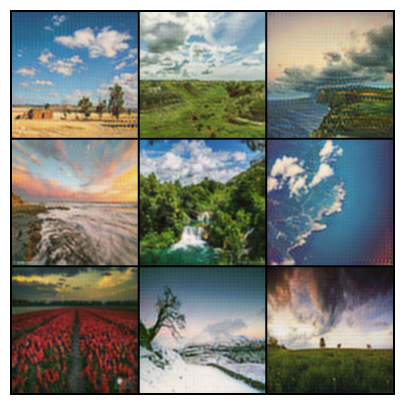

Epoch 34:   0%|          | 0/509 [00:00<?, ?it/s]

-- Batches for Epoch 34 --: 0it [00:00, ?it/s]

|                  34|          2.17418211|          0.01335720|          1.33341491|
+--------------------+--------------------+--------------------+--------------------+
Displaying 9 original photos and 9 generated paintings after Epoch 34
Original Photos:


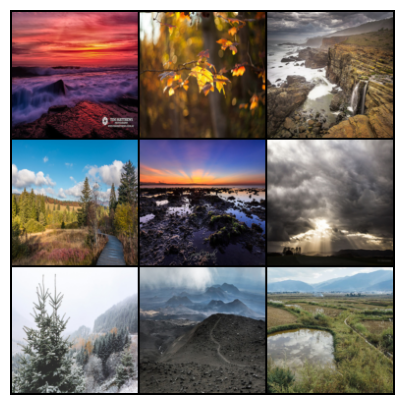

Generated Paintings:


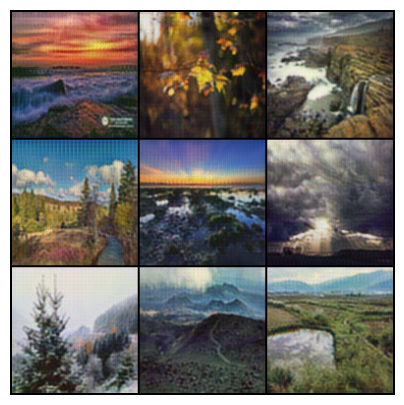

Epoch 35:   0%|          | 0/509 [00:00<?, ?it/s]

-- Batches for Epoch 35 --: 0it [00:00, ?it/s]

|                  35|          2.12148613|          0.03049920|          1.39518899|
+--------------------+--------------------+--------------------+--------------------+
Displaying 9 original photos and 9 generated paintings after Epoch 35
Original Photos:


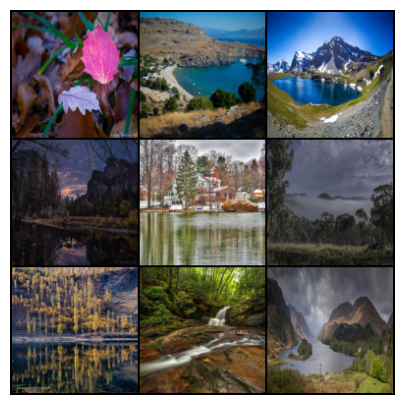

Generated Paintings:


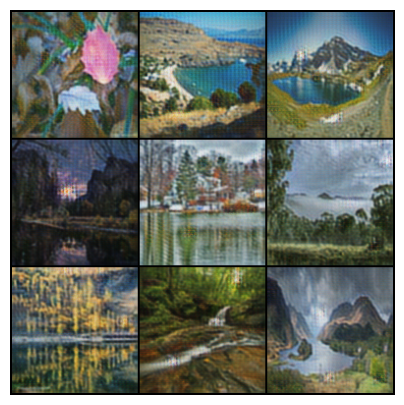

Epoch 36:   0%|          | 0/509 [00:00<?, ?it/s]

-- Batches for Epoch 36 --: 0it [00:00, ?it/s]

|                  36|          2.16043007|          0.01533102|          1.19037568|
+--------------------+--------------------+--------------------+--------------------+
Displaying 9 original photos and 9 generated paintings after Epoch 36
Original Photos:


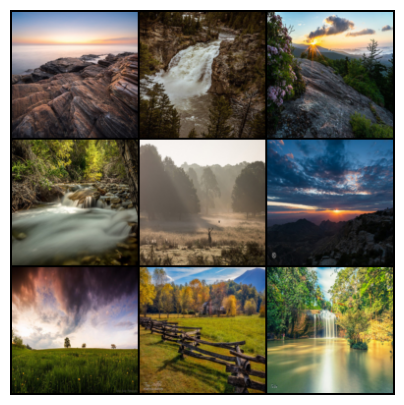

Generated Paintings:


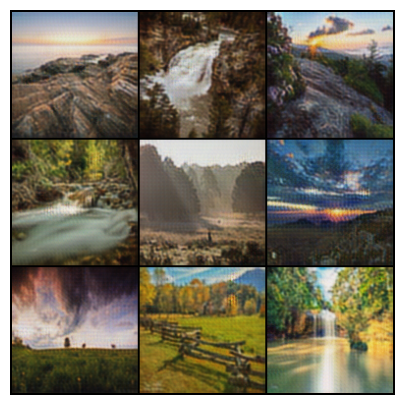

BEST MODEL SAVED with val_loss: 1.19037568 at epoch 36


Epoch 37:   0%|          | 0/509 [00:00<?, ?it/s]

-- Batches for Epoch 37 --: 0it [00:00, ?it/s]

|                  37|          2.16447247|          0.01840889|          1.30520948|
+--------------------+--------------------+--------------------+--------------------+
Displaying 9 original photos and 9 generated paintings after Epoch 37
Original Photos:


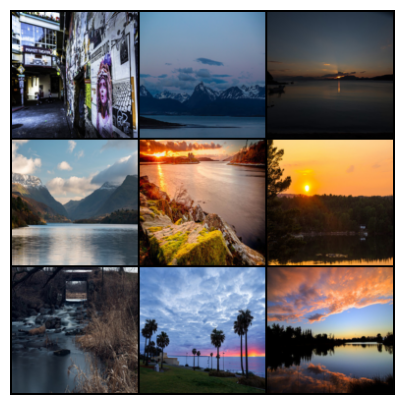

Generated Paintings:


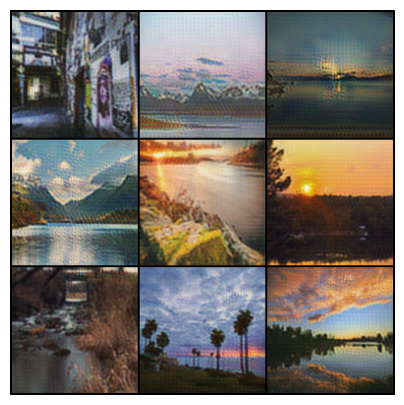

Epoch 38:   0%|          | 0/509 [00:00<?, ?it/s]

-- Batches for Epoch 38 --: 0it [00:00, ?it/s]

|                  38|          2.14175966|          0.00961190|          1.24917810|
+--------------------+--------------------+--------------------+--------------------+
Displaying 9 original photos and 9 generated paintings after Epoch 38
Original Photos:


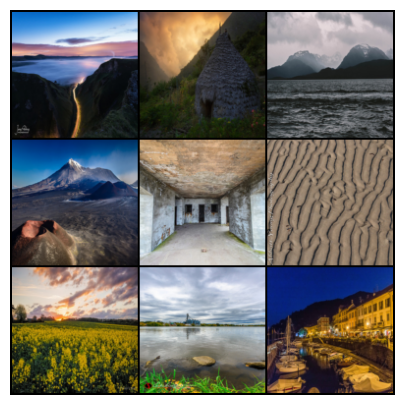

Generated Paintings:


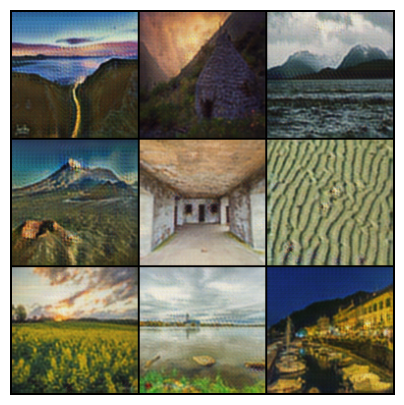

Epoch 39:   0%|          | 0/509 [00:00<?, ?it/s]

-- Batches for Epoch 39 --: 0it [00:00, ?it/s]

|                  39|          1.97581227|          0.07666273|          1.16547336|
+--------------------+--------------------+--------------------+--------------------+
Displaying 9 original photos and 9 generated paintings after Epoch 39
Original Photos:


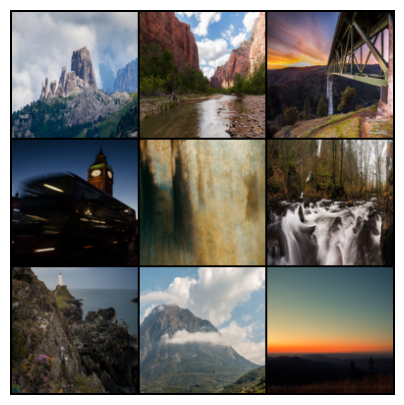

Generated Paintings:


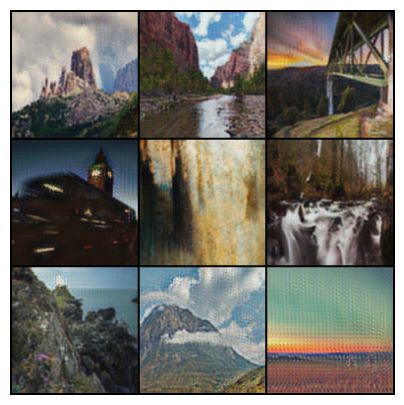

BEST MODEL SAVED with val_loss: 1.16547336 at epoch 39
TRAINING FINISHED !!!


In [10]:
def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
        torch.nn.init.constant_(m.bias, 0)


def load_checkpoint(path='/kaggle/working/last_checkpoint.pth'):
    if os.path.exists(path):
        ckpt = torch.load(path, map_location=device)
        gen_AB.load_state_dict(ckpt['gen_AB'])
        gen_BA.load_state_dict(ckpt['gen_BA'])
        disc_B.load_state_dict(ckpt['disc_B'])
        gen_opt.load_state_dict(ckpt['gen_opt'])
        disc_opt.load_state_dict(ckpt['disc_opt'])
        start_epoch = ckpt.get('epoch', 0)
        best_val_loss = ckpt.get('best_val_loss',float('inf'))
        data = ckpt.get('completed_epochs_data', [])
        print(f"Loaded epoch {start_epoch}")
        return start_epoch, data, best_val_loss
    else:
        gen_AB.apply(weights_init)
        gen_BA.apply(weights_init)
        disc_B.apply(weights_init)
        print("Starting fresh")
        return 0, [], float('inf')


start_epoch, completed_epochs_data, best_val_loss = load_checkpoint()


def train_model(start_epoch=0, completed_epochs_data=None, best_val_loss=float('inf'), save_model=True, save_best_model=True):
    if completed_epochs_data is None:
        completed_epochs_data = []

    print(generate_header())
    for data in completed_epochs_data:
        print(generate_data_line(data))
        print(get_segmented_border())

    try:
        overall_progress = tqdm(total=NUM_EPOCHS, desc="Overall Progress", position=0)
        overall_progress.update(start_epoch)

        for epoch in range(start_epoch, NUM_EPOCHS):
            gen_AB.train()
            gen_BA.train()
            disc_B.train()

            total_gen_loss = 0
            total_disc_loss = 0
            num_batches = len(train_loader)

            current_epoch_progress = tqdm(total=num_batches, desc=f"Epoch {epoch+1}", position=1, leave=True)
            current_batch_progress = tqdm(total=0, desc=f"-- Batches for Epoch {epoch+1} --", position=2, leave=False)

            for batch_idx, (real_photo, real_paint) in enumerate(train_loader):
                real_photo = F.interpolate(real_photo, size=(TARGET_SHAPE, TARGET_SHAPE)).to(device)
                real_paint = F.interpolate(real_paint, size=(TARGET_SHAPE, TARGET_SHAPE)).to(device)

                # --- Train Discriminator ---
                disc_opt.zero_grad()
                with torch.no_grad():
                    fake_paint = gen_AB(real_photo)
                disc_loss = get_disc_loss(real_paint, fake_paint, disc_B)
                disc_loss.backward()
                disc_opt.step()

                # --- Train Generator ---
                gen_opt.zero_grad()
                gen_loss, fake_paint = get_gen_loss(real_photo, real_paint, gen_AB, gen_BA, disc_B)
                gen_loss.backward()
                gen_opt.step()

                total_gen_loss += gen_loss.item()
                total_disc_loss += disc_loss.item()

                mean_gen_loss = total_gen_loss / (batch_idx + 1)
                mean_disc_loss = total_disc_loss / (batch_idx + 1)

                current_epoch_progress.update(1)
                current_batch_progress.set_description(
                    f"[Batch {batch_idx+1:03d}] Gen: {gen_loss.item():.8f}, Disc: {disc_loss.item():.8f}"
                )
                current_batch_progress.update(1)

            avg_gen_loss = total_gen_loss / num_batches
            avg_disc_loss = total_disc_loss / num_batches

            # --- Validation ---
            gen_AB.eval()
            gen_BA.eval()
            disc_B.eval()

            total_val_loss = 0
            with torch.no_grad():
                for real_photo, real_paint in val_loader:
                    real_photo = F.interpolate(real_photo, size=(TARGET_SHAPE, TARGET_SHAPE)).to(device)
                    real_paint = F.interpolate(real_paint, size=(TARGET_SHAPE, TARGET_SHAPE)).to(device)

                    fake_paint = gen_AB(real_photo)
                    cycled_photo = gen_BA(fake_paint)
                    cycle_loss = recon_criterion(cycled_photo, real_photo)
                    identity_paint = gen_AB(real_paint)
                    id_loss = recon_criterion(identity_paint, real_paint)
                    val_loss = LAMBDA_CYCLE * cycle_loss + LAMBDA_IDENTITY * id_loss
                    total_val_loss += val_loss.item()

            avg_val_loss = total_val_loss / len(val_loader)

            new_data = [epoch + 1, avg_gen_loss, avg_disc_loss, avg_val_loss]
            completed_epochs_data.append(new_data)
            print(generate_data_line(new_data))
            print(get_segmented_border())

            current_epoch_progress.set_description(f"Epoch {epoch+1} | Val: {avg_val_loss:.8f}")
            current_epoch_progress.close()
            current_batch_progress.close()
            overall_progress.update(1)

            # Show results after each epoch 
            print(f"Displaying 9 original photos and 9 generated paintings after Epoch {epoch+1}")
            with torch.no_grad():
                random_indices = random.sample(range(len(val_ds)), 9)
                real_photo = torch.stack([val_ds[idx][0] for idx in random_indices]).to(device)
                real_photo = F.interpolate(real_photo, size=(TARGET_SHAPE, TARGET_SHAPE))
                fake_paint = gen_AB(real_photo)

                print("Original Photos:")
                show_tensor_images(real_photo, num_images=9)

                print("Generated Paintings:")
                show_tensor_images(fake_paint, num_images=9)

            checkpoint = {
                'epoch': epoch + 1,
                'best_val_loss' : best_val_loss,
                'gen_AB': gen_AB.state_dict(),
                'gen_BA': gen_BA.state_dict(),
                'disc_B': disc_B.state_dict(),
                'gen_opt': gen_opt.state_dict(),
                'disc_opt': disc_opt.state_dict(),
                'completed_epochs_data': completed_epochs_data
            }

            if save_model:
                torch.save(checkpoint, '/kaggle/working/last_checkpoint.pth')

            if save_best_model and avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                torch.save(checkpoint, '/kaggle/working/best_checkpoint.pth')
                print(f"BEST MODEL SAVED with val_loss: {best_val_loss:.8f} at epoch {epoch+1}")

        print("TRAINING FINISHED !!!")

    except KeyboardInterrupt:
        print("Training Cancelled !!!")

    finally:
        overall_progress.close()


train_model(start_epoch=start_epoch, completed_epochs_data=completed_epochs_data, best_val_loss=best_val_loss)

Datas from checkpoint:
Epoch 1: Gen Loss = 3.72611391, Disc Loss = 0.30570305, Val Loss = 2.76648529
Epoch 2: Gen Loss = 2.78364931, Disc Loss = 0.24655354, Val Loss = 2.26839313
Epoch 3: Gen Loss = 2.56734749, Disc Loss = 0.23637920, Val Loss = 2.72778771
Epoch 4: Gen Loss = 2.80851916, Disc Loss = 0.11681689, Val Loss = 2.47194129
Epoch 5: Gen Loss = 2.91252179, Disc Loss = 0.03756399, Val Loss = 2.39799391
Epoch 6: Gen Loss = 2.85379455, Disc Loss = 0.03162234, Val Loss = 2.06807409
Epoch 7: Gen Loss = 2.77157628, Disc Loss = 0.03203327, Val Loss = 1.90269518
Epoch 8: Gen Loss = 2.72855082, Disc Loss = 0.02172121, Val Loss = 1.86774785
Epoch 9: Gen Loss = 2.66909807, Disc Loss = 0.01292169, Val Loss = 1.67987512
Epoch 10: Gen Loss = 2.62019630, Disc Loss = 0.01063887, Val Loss = 1.58258953
Epoch 11: Gen Loss = 2.55554540, Disc Loss = 0.02716621, Val Loss = 1.99931751
Epoch 12: Gen Loss = 2.54411953, Disc Loss = 0.01224551, Val Loss = 1.49243373
Epoch 13: Gen Loss = 2.50766357, Disc 

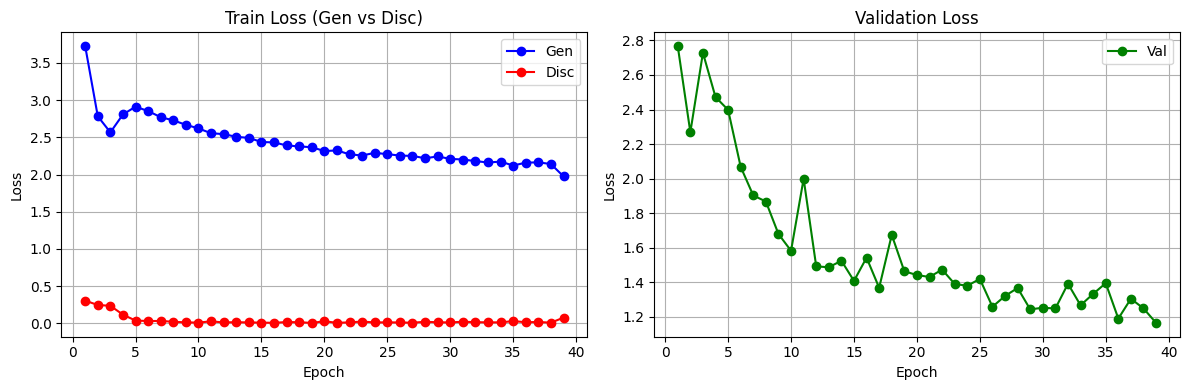

In [11]:
# Load checkpoint 
ckpt = torch.load('/kaggle/working/last_checkpoint.pth')
data = ckpt['completed_epochs_data']

epochs = [d[0] for d in data]
gen_losses = [d[1] for d in data]      # Gen Loss
disc_losses = [d[2] for d in data]     # Disc Loss 
val_losses = [d[3] for d in data]      # Val Loss

print("Datas from checkpoint:")
for epoch, gen_l, disc_l, val_l in data:
    print(f"Epoch {epoch}: Gen Loss = {gen_l:.8f}, Disc Loss = {disc_l:.8f}, Val Loss = {val_l:.8f}")

# Plot 1: Gen + Disc (Train) | Plot 2: Val
plt.figure(figsize=(12, 4))

plt.subplot(121)
plt.plot(epochs, gen_losses, 'b-o', label='Gen')
plt.plot(epochs, disc_losses, 'r-o', label='Disc')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train Loss (Gen vs Disc)')
plt.legend()
plt.grid(True)

plt.subplot(122)
plt.plot(epochs, val_losses, 'g-o', label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()